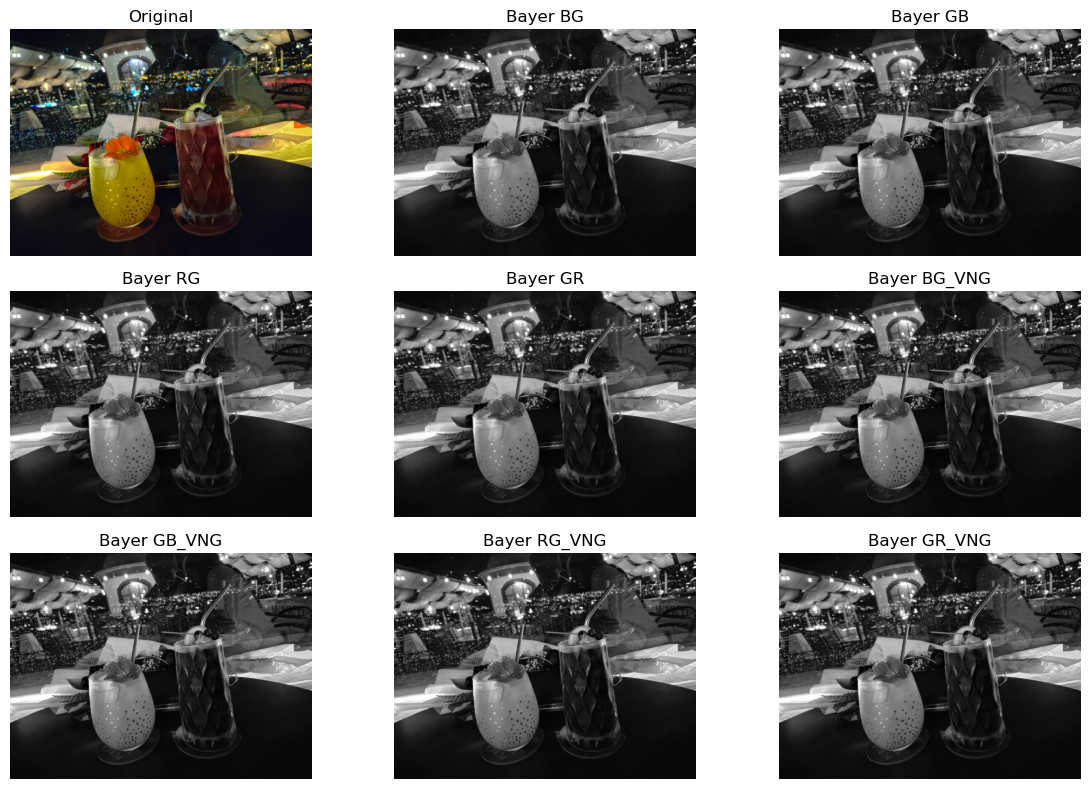

In [12]:
import cv2
import matplotlib.pyplot as plt

# función RGB -> YUV -> RGB
def transformar_yuv(img):

    yuv = cv2.cvtColor(img, cv2.COLOR_BGR2YUV)
    rgb = cv2.cvtColor(yuv, cv2.COLOR_YUV2BGR)

    return rgb


imagen = cv2.imread("colores.jpeg")

# crear imagen RAW Bayer simulada
bayer = imagen[:,:,1]   # canal verde (simula sensor)

filtros = [
    ("BG", cv2.COLOR_BAYER_BG2BGR),
    ("GB", cv2.COLOR_BAYER_GB2BGR),
    ("RG", cv2.COLOR_BAYER_RG2BGR),
    ("GR", cv2.COLOR_BAYER_GR2BGR),
    ("BG_VNG", cv2.COLOR_BAYER_BG2BGR_VNG),
    ("GB_VNG", cv2.COLOR_BAYER_GB2BGR_VNG),
    ("RG_VNG", cv2.COLOR_BAYER_RG2BGR_VNG),
    ("GR_VNG", cv2.COLOR_BAYER_GR2BGR_VNG)
]

plt.figure(figsize=(12,8))

# original
plt.subplot(3,3,1)
plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
plt.title("Original")
plt.axis("off")

for i,(nombre,filtro) in enumerate(filtros):

    img_bayer = cv2.cvtColor(bayer, filtro)

    resultado = transformar_yuv(img_bayer)

    plt.subplot(3,3,i+2)
    plt.imshow(cv2.cvtColor(resultado, cv2.COLOR_BGR2RGB))
    plt.title("Bayer "+nombre)
    plt.axis("off")

plt.tight_layout()
plt.show()


yub rgb

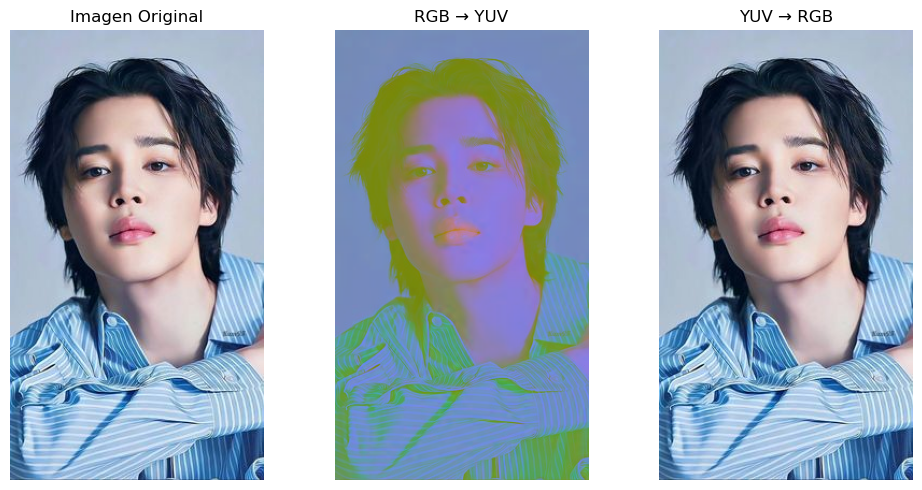

In [10]:
import cv2
import matplotlib.pyplot as plt

def convertir_color(imagen, tipo):

    if tipo == "RGB2YUV":
        return cv2.cvtColor(imagen, cv2.COLOR_BGR2YUV)

    elif tipo == "YUV2RGB":
        return cv2.cvtColor(imagen, cv2.COLOR_YUV2BGR)

    else:
        print("Tipo de conversión no válido")
        return imagen

imagen = cv2.imread("image.png")

imagen_yuv = convertir_color(imagen, "RGB2YUV")
imagen_rgb = convertir_color(imagen_yuv, "YUV2RGB")

plt.figure(figsize=(10,5))

plt.subplot(1,3,1)
plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
plt.title("Imagen Original")
plt.axis("off")

plt.subplot(1,3,2)
plt.imshow(cv2.cvtColor(imagen_yuv, cv2.COLOR_BGR2RGB))
plt.title("RGB → YUV")
plt.axis("off")

plt.subplot(1,3,3)
plt.imshow(cv2.cvtColor(imagen_rgb, cv2.COLOR_BGR2RGB))
plt.title("YUV → RGB")
plt.axis("off")

plt.tight_layout()
plt.show()


Se une todo

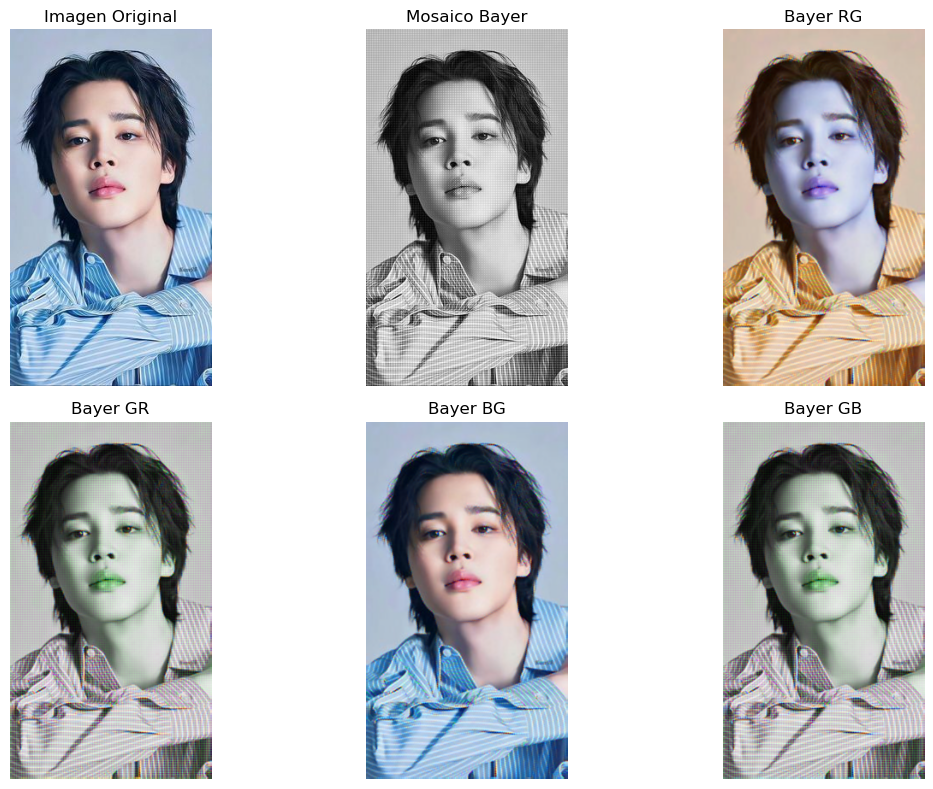

In [17]:
import cv2
import numpy as np
import matplotlib.pyplot as plt


# -----------------------------
# 1. Crear mosaico Bayer RGGB
# -----------------------------
def crear_mosaico_bayer(img):

    alto, ancho, _ = img.shape
    mosaico = np.zeros((alto, ancho), dtype=np.uint8)

    B, G, R = cv2.split(img)

    for i in range(alto):
        for j in range(ancho):

            if i % 2 == 0 and j % 2 == 0:      # R
                mosaico[i, j] = R[i, j]

            elif i % 2 == 0 and j % 2 == 1:    # G
                mosaico[i, j] = G[i, j]

            elif i % 2 == 1 and j % 2 == 0:    # G
                mosaico[i, j] = G[i, j]

            else:                              # B
                mosaico[i, j] = B[i, j]

    return mosaico


# -----------------------------
# 2. Reconstrucción Bayer
# -----------------------------
def reconstruir_bayer(mosaico, tipo):

    if tipo == "RG":
        return cv2.cvtColor(mosaico, cv2.COLOR_BAYER_RG2BGR)

    elif tipo == "GR":
        return cv2.cvtColor(mosaico, cv2.COLOR_BAYER_GR2BGR)

    elif tipo == "BG":
        return cv2.cvtColor(mosaico, cv2.COLOR_BAYER_BG2BGR)

    elif tipo == "GB":
        return cv2.cvtColor(mosaico, cv2.COLOR_BAYER_GB2BGR)


# -----------------------------
# 3. Cargar imagen
# -----------------------------
imagen = cv2.imread("image.png")

# crear mosaico
mosaico = crear_mosaico_bayer(imagen)

# reconstrucciones
rg = reconstruir_bayer(mosaico, "RG")
gr = reconstruir_bayer(mosaico, "GR")
bg = reconstruir_bayer(mosaico, "BG")
gb = reconstruir_bayer(mosaico, "GB")


# -----------------------------
# 4. Mostrar resultados
# -----------------------------
plt.figure(figsize=(12,8))

plt.subplot(2,3,1)
plt.imshow(cv2.cvtColor(imagen, cv2.COLOR_BGR2RGB))
plt.title("Imagen Original")
plt.axis("off")

plt.subplot(2,3,2)
plt.imshow(mosaico, cmap="gray")
plt.title("Mosaico Bayer")
plt.axis("off")

plt.subplot(2,3,3)
plt.imshow(cv2.cvtColor(rg, cv2.COLOR_BGR2RGB))
plt.title("Bayer RG")
plt.axis("off")

plt.subplot(2,3,4)
plt.imshow(cv2.cvtColor(gr, cv2.COLOR_BGR2RGB))
plt.title("Bayer GR")
plt.axis("off")

plt.subplot(2,3,5)
plt.imshow(cv2.cvtColor(bg, cv2.COLOR_BGR2RGB))
plt.title("Bayer BG")
plt.axis("off")

plt.subplot(2,3,6)
plt.imshow(cv2.cvtColor(gb, cv2.COLOR_BGR2RGB))
plt.title("Bayer GB")
plt.axis("off")

plt.tight_layout()
plt.show()
